# Lab 3: Trực quan hóa Word Embeddings

**Họ và tên**: Trần Minh Đức  
**MSV**: 23001518  
**Lớp**: 68KHDL

## Mục tiêu
- Sử dụng kỹ thuật giảm chiều (PCA, t-SNE) để giảm word vectors từ không gian nhiều chiều xuống 2D
- Trực quan hóa 5,000 từ trong không gian 2D để quan sát mối quan hệ ngữ nghĩa giữa các từ
- Trực quan các từ theo từng nhóm nghĩa theo PCA và T-SNE
- Tìm và trực quan các từ gần nghĩa với `computer`

## 1: Cài đặt thư viện và tải mô hình Word Embeddings

### Thư viện:
- **gensim**: Thư viện chuyên về xử lý NLP, hỗ trợ tải và làm việc với word embeddings
- **scikit-learn**: Cung cấp các thuật toán giảm chiều như PCA, t-SNE
- **matplotlib**: Thư viện vẽ đồ thị để trực quan hóa
- **numpy**: Xử lý ma trận và vector hiệu quả

### Mô hình GloVe:
- **GloVe** (Global Vectors for Word Representation) là mô hình pre-trained được huấn luyện trên Wikipedia + Gigaword corpus (hàng tỷ từ)
- Mỗi từ được biểu diễn bằng vector 100 chiều
- Ưu điểm: Nhanh, chất lượng cao, không cần huấn luyện lại

In [29]:
# Cài đặt các thư viện cần thiết
!pip install gensim scikit-learn matplotlib numpy

In [30]:
import gensim.downloader as api
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Tải mô hình GloVe pre-trained (100 chiều, 400K từ vựng)
print("Đang tải mô hình GloVe")
model = api.load('glove-wiki-gigaword-100')
print(f"Đã tải xong! Số lượng từ trong từ vựng: {len(model.index_to_key):,}")

Đang tải mô hình GloVe
Đã tải xong! Số lượng từ trong từ vựng: 400,000
Đã tải xong! Số lượng từ trong từ vựng: 400,000


## 2: Chọn 5,000 từ để trực quan hóa

### Lý do chọn 5,000 từ:
- **Cân bằng giữa tốc độ và độ chính xác**: 
  - Đủ lớn để quan sát được các cluster ngữ nghĩa
  - Đủ nhỏ để t-SNE chạy trong thời gian hợp lý
- **Từ phổ biến nhất**: Đảm bảo các từ được chọn có ý nghĩa và thường dùng

### Kích thước dữ liệu:
- Input: 5,000 từ × 100 chiều = Ma trận 5000×100
- Output sau giảm chiều: 5000×2 (để vẽ 2D)

In [31]:
# Chọn 5,000 từ phổ biến nhất
NUM_WORDS = 5000
words_to_visualize = model.index_to_key[:NUM_WORDS]

# Lấy vectors tương ứng
word_vectors = np.array([model[word] for word in words_to_visualize])

print(f"Đã chọn {len(words_to_visualize):,} từ")
print(f"Kích thước ma trận vectors: {word_vectors.shape}")
print(f"Ví dụ 10 từ đầu tiên: {words_to_visualize[:10]}")

Đã chọn 5,000 từ
Kích thước ma trận vectors: (5000, 100)
Ví dụ 10 từ đầu tiên: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"]


## 3: Giảm chiều với PCA

### Về PCA (Principal Component Analysis):

**Nguyên lý hoạt động:**
- PCA tìm các **trục chính** (principal components) của dữ liệu
- Trục PC1: Hướng có phương sai lớn nhất
- Trục PC2: Hướng vuông góc với PC1, có phương sai lớn thứ hai
- Giảm 100 chiều → 2 chiều bằng cách chiếu lên 2 trục này

**Ưu điểm:**
- Nhanh, hiệu quả O(n²d) với n=5000 từ, d=100 chiều
- Kết quả ổn định (deterministic với cùng random_state)

**Nhược điểm:**
- Tuyến tính → không bắt được quan hệ phi tuyến
- Mất nhiều thông tin (chỉ giữ ~15-25% phương sai)

In [32]:
print("Đang thực hiện giảm chiều với PCA...")

# Giảm chiều xuống 2D
pca = PCA(n_components=2, random_state=42)
vectors_2d_pca = pca.fit_transform(word_vectors)

print(f"Hoàn thành! Kích thước sau giảm chiều: {vectors_2d_pca.shape}")

Đang thực hiện giảm chiều với PCA...
Hoàn thành! Kích thước sau giảm chiều: (5000, 2)


### Phân tích kết quả PCA:

**Explained Variance Ratio** (Tỷ lệ phương sai được giữ lại):
- Cho biết bao nhiêu % thông tin được bảo toàn sau giảm chiều
- Với 2 chiều, thường đạt ~10%

**Ý nghĩa:**
- Dù chỉ giữ ~10% thông tin, vẫn đủ để quan sát các mối quan hệ cơ bản
- 90% còn lại bị mất do hạn chế của không gian 2D

## 4: Trực quan hóa với PCA (2D)

### Phân tích biểu đồ:

**Quan sát:**
- Các từ phân tán đều trong không gian 2D
- Có sự phân cụm nhẹ nhưng không rõ ràng
- Ranh giới giữa các nhóm từ mờ nhạt

**Giải thích:**
- PCA là phương pháp **tuyến tính** → không tách rõ các cluster phi tuyến
- Bảo toàn khoảng cách toàn cục → từ xa nhau trong 100D vẫn xa trong 2D
- Phù hợp để có **cái nhìn tổng quan** về phân bố dữ liệu

**Trực quan hóa:**
- Vẽ tất cả 5,000 điểm (màu xanh, alpha thấp)
- Hiển thị label cho 200 từ phổ biến nhất để tránh lộn xộn

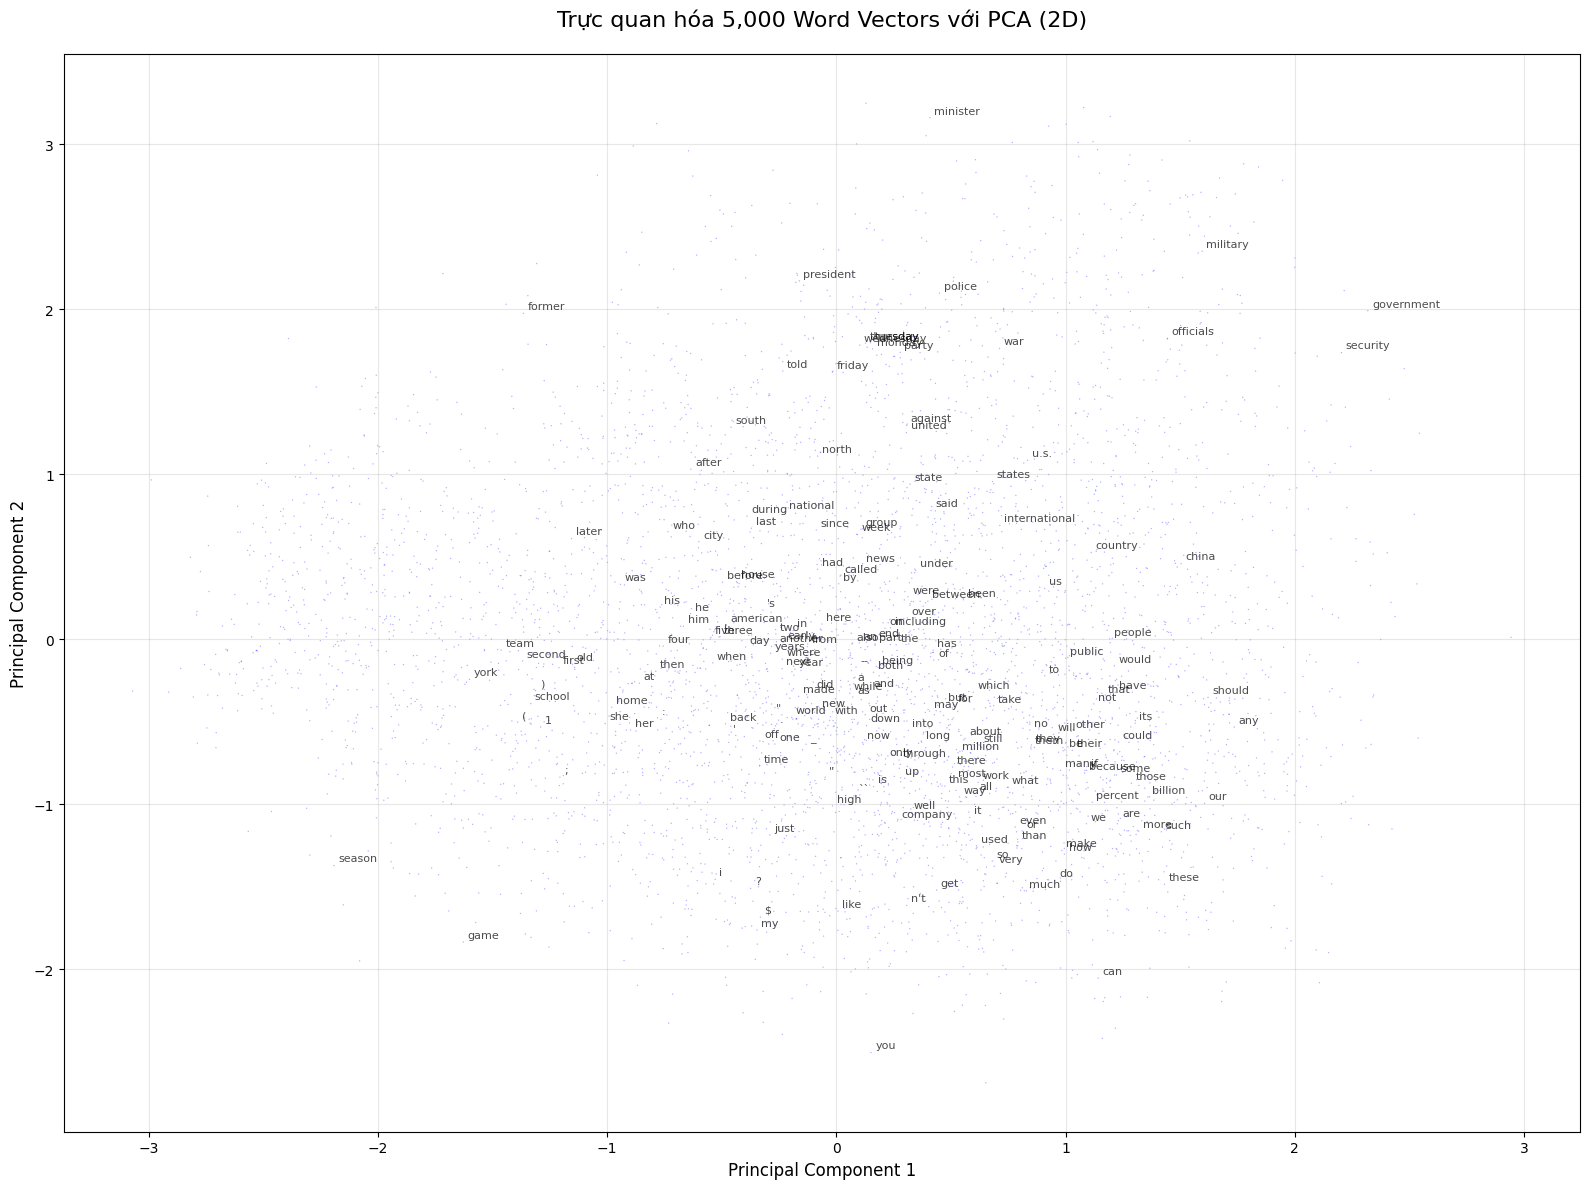

Đã trực quan hóa 5,000 từ với PCA


In [33]:
plt.figure(figsize=(16, 12))

# Vẽ tất cả 5,000 điểm
plt.scatter(vectors_2d_pca[:, 0], vectors_2d_pca[:, 1], 
           alpha=0.3, s=1, c='blue', edgecolors='none')

# Hiển thị nhãn cho 200 từ phổ biến nhất (để dễ đọc)
NUM_LABELS = 200
for i in range(NUM_LABELS):
    plt.annotate(words_to_visualize[i], 
                xy=(vectors_2d_pca[i, 0], vectors_2d_pca[i, 1]),
                xytext=(3, 3), 
                textcoords='offset points',
                fontsize=8,
                alpha=0.7)

plt.title(f'Trực quan hóa {NUM_WORDS:,} Word Vectors với PCA (2D)', fontsize=16, pad=20)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Đã trực quan hóa {NUM_WORDS:,} từ với PCA")

## 5: Giảm chiều với t-SNE

### Về t-SNE (t-Distributed Stochastic Neighbor Embedding):

**Nguyên lý hoạt động:**
1. Tính **xác suất tương đồng** giữa các cặp điểm trong không gian 100D
2. Khởi tạo ngẫu nhiên vị trí trong không gian 2D
3. Tối ưu hóa để **xác suất trong 2D** giống với **xác suất trong 100D**
4. Sử dụng phân phối Student's

**Ưu điểm:**
- Bảo toàn cấu trúc **cục bộ** rất tốt
- Tạo ra các **cluster rõ ràng**
- Phát hiện được quan hệ **phi tuyến**

**Nhược điểm:**
- Chậm O(n² log n) 
- Không bảo toàn khoảng cách toàn cục
- Stochastic - kết quả thay đổi mỗi lần chạy

**Tham số quan trọng:**
- `perplexity=30`: Cân bằng giữa cấu trúc local và global
- `max_iter=1000`: Số vòng lặp tối ưu hóa
- `random_state=42`: Đảm bảo kết quả có thể tái tạo

In [34]:
print("Đang thực hiện giảm chiều với t-SNE")
print("Đang xử lý...")

# Giảm chiều xuống 2D với t-SNE
tsne = TSNE(n_components=2, 
           random_state=42,
           perplexity=30,
           max_iter=1000, 
           verbose=1)

vectors_2d_tsne = tsne.fit_transform(word_vectors)

print(f"Hoàn thành! Kích thước sau giảm chiều: {vectors_2d_tsne.shape}")

Đang thực hiện giảm chiều với t-SNE
Đang xử lý...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.003s...
[t-SNE] Computed neighbors for 5000 samples in 0.186s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 1.606389
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 1.606389
[t-SNE] KL divergence after 250 iterations with early exaggeration: 87.412743
[t-SNE] KL di

## 6: Trực quan hóa với t-SNE (2D)

### Phân tích biểu đồ:

**Quan sát:**
- Các từ tạo thành **các cluster rõ ràng**, tách biệt hơn PCA
- Từ cùng ngữ nghĩa/chủ đề **nhóm lại gần nhau**
- Có khoảng trống giữa các cluster

**So sánh với PCA:**
| Tiêu chí | PCA | t-SNE |
|----------|-----|-------|
| Cluster | Mờ nhạt | Rõ ràng |
| Phân tách | Liên tục | Có khoảng trống |
| Cấu trúc cục bộ | Yếu | Mạnh |
| Hiệu quả cho NLP | Trung bình | Tốt |

**Lợi ích:**
- t-SNE phù hợp để **khám phá** cấu trúc ngữ nghĩa
- Giúp **trực quan hóa** mối quan hệ giữa các từ

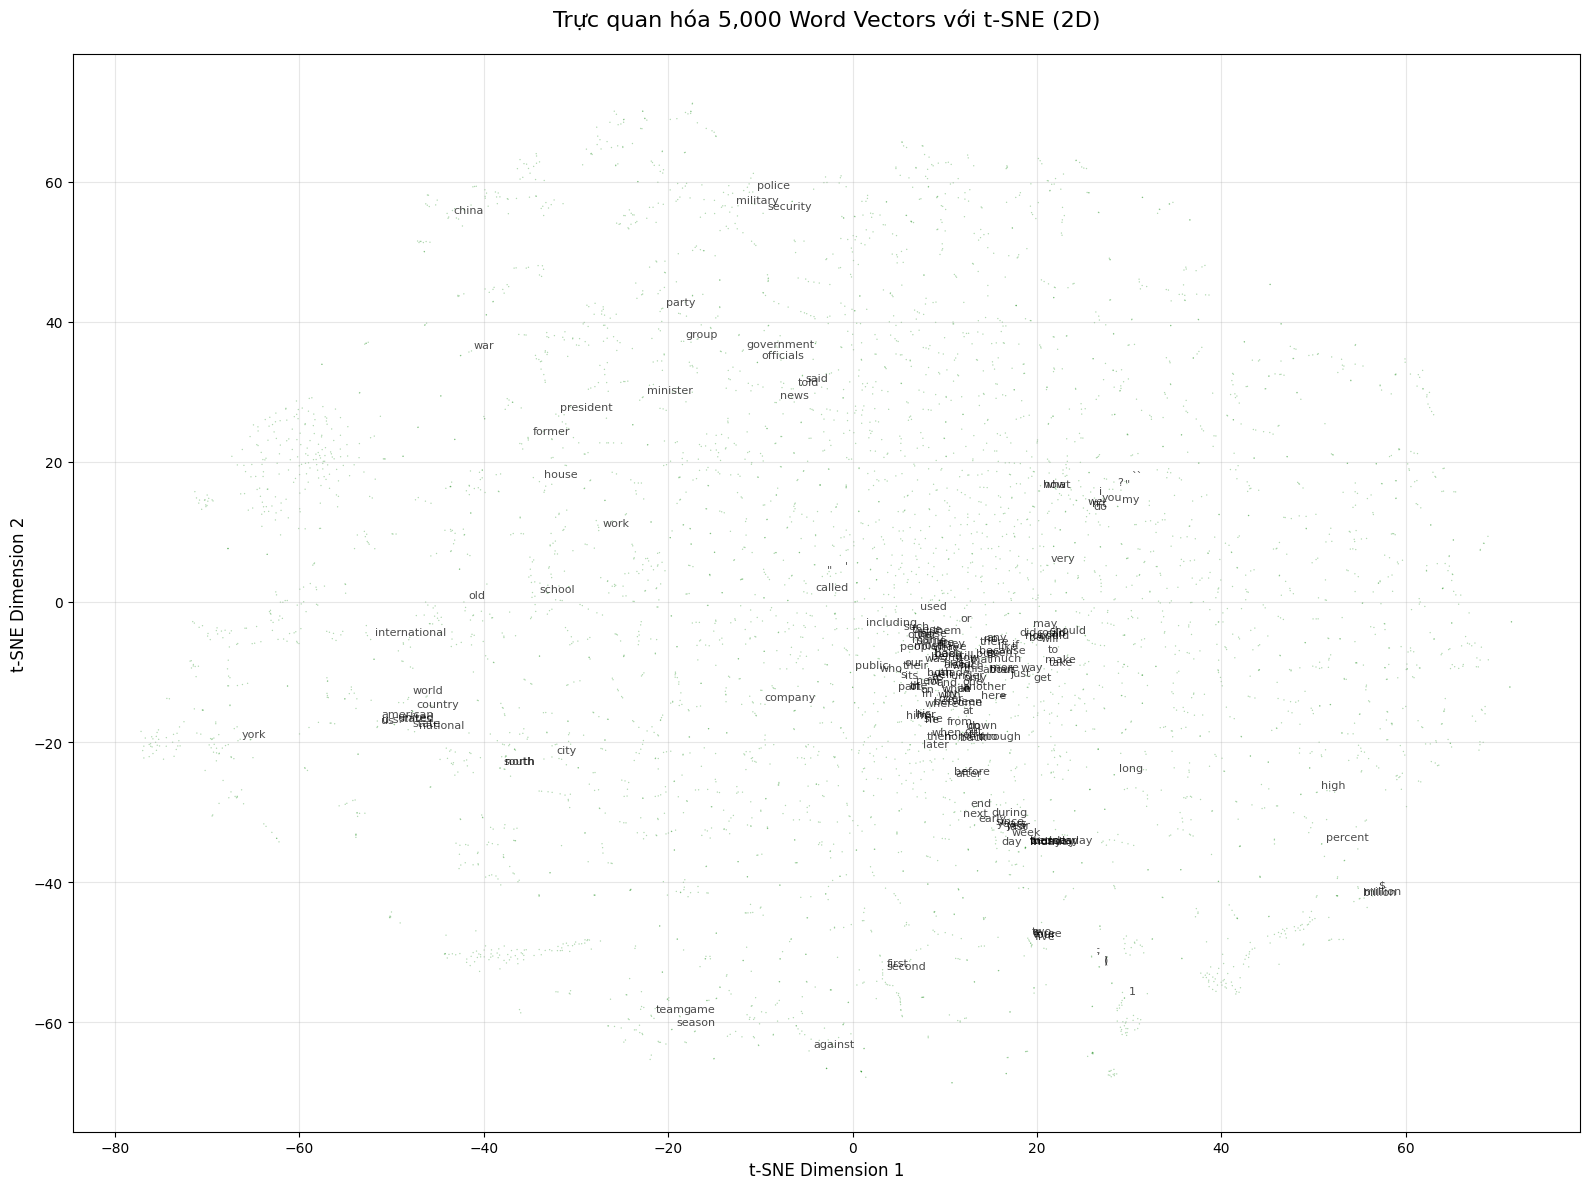

Đã trực quan hóa 5,000 từ với t-SNE


In [35]:
plt.figure(figsize=(16, 12))

# Vẽ tất cả 5000 điểm
plt.scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], 
           alpha=0.3, s=1, c='green', edgecolors='none')

# Hiển thị nhãn cho 200 từ phổ biến nhất
NUM_LABELS = 200
for i in range(NUM_LABELS):
    plt.annotate(words_to_visualize[i], 
                xy=(vectors_2d_tsne[i, 0], vectors_2d_tsne[i, 1]),
                xytext=(3, 3), 
                textcoords='offset points',
                fontsize=8,
                alpha=0.7)

plt.title(f'Trực quan hóa {NUM_WORDS:,} Word Vectors với t-SNE (2D)', fontsize=16, pad=20)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Đã trực quan hóa {NUM_WORDS:,} từ với t-SNE")

## 7: So sánh PCA và t-SNE

### Mục đích:
Đặt hai biểu đồ cạnh nhau để **so sánh trực quan** sự khác biệt giữa hai phương pháp

### Điểm khác biệt rõ nhất:

**1. Độ phân tán:**
- PCA: Từ phân bố đều, không có ranh giới rõ
- t-SNE: Từ tập trung thành từng đám, có khoảng trống

**2. Bảo toàn thông tin:**
- PCA: Bảo toàn khoảng cách toàn cục (từ xa nhau vẫn xa)
- t-SNE: Bảo toàn láng giềng gần (từ gần nhau vẫn gần)

**3. Khả năng phân nhóm:**
- PCA: Khó phân biệt các nhóm từ
- t-SNE: Các nhóm từ tách biệt rõ ràng

### Khi nào dùng phương pháp nào?

**Dùng PCA khi:**
- Cần tốc độ nhanh
- Dữ liệu lớn
- Cần bảo toàn khoảng cách tuyệt đối
- Cần kết quả ổn định, reproducible

**Dùng t-SNE khi:**
- Cần trực quan hóa cluster
- Khám phá cấu trúc dữ liệu
- Dữ liệu vừa và nhỏ
- Chấp nhận thời gian xử lý lâu hơn

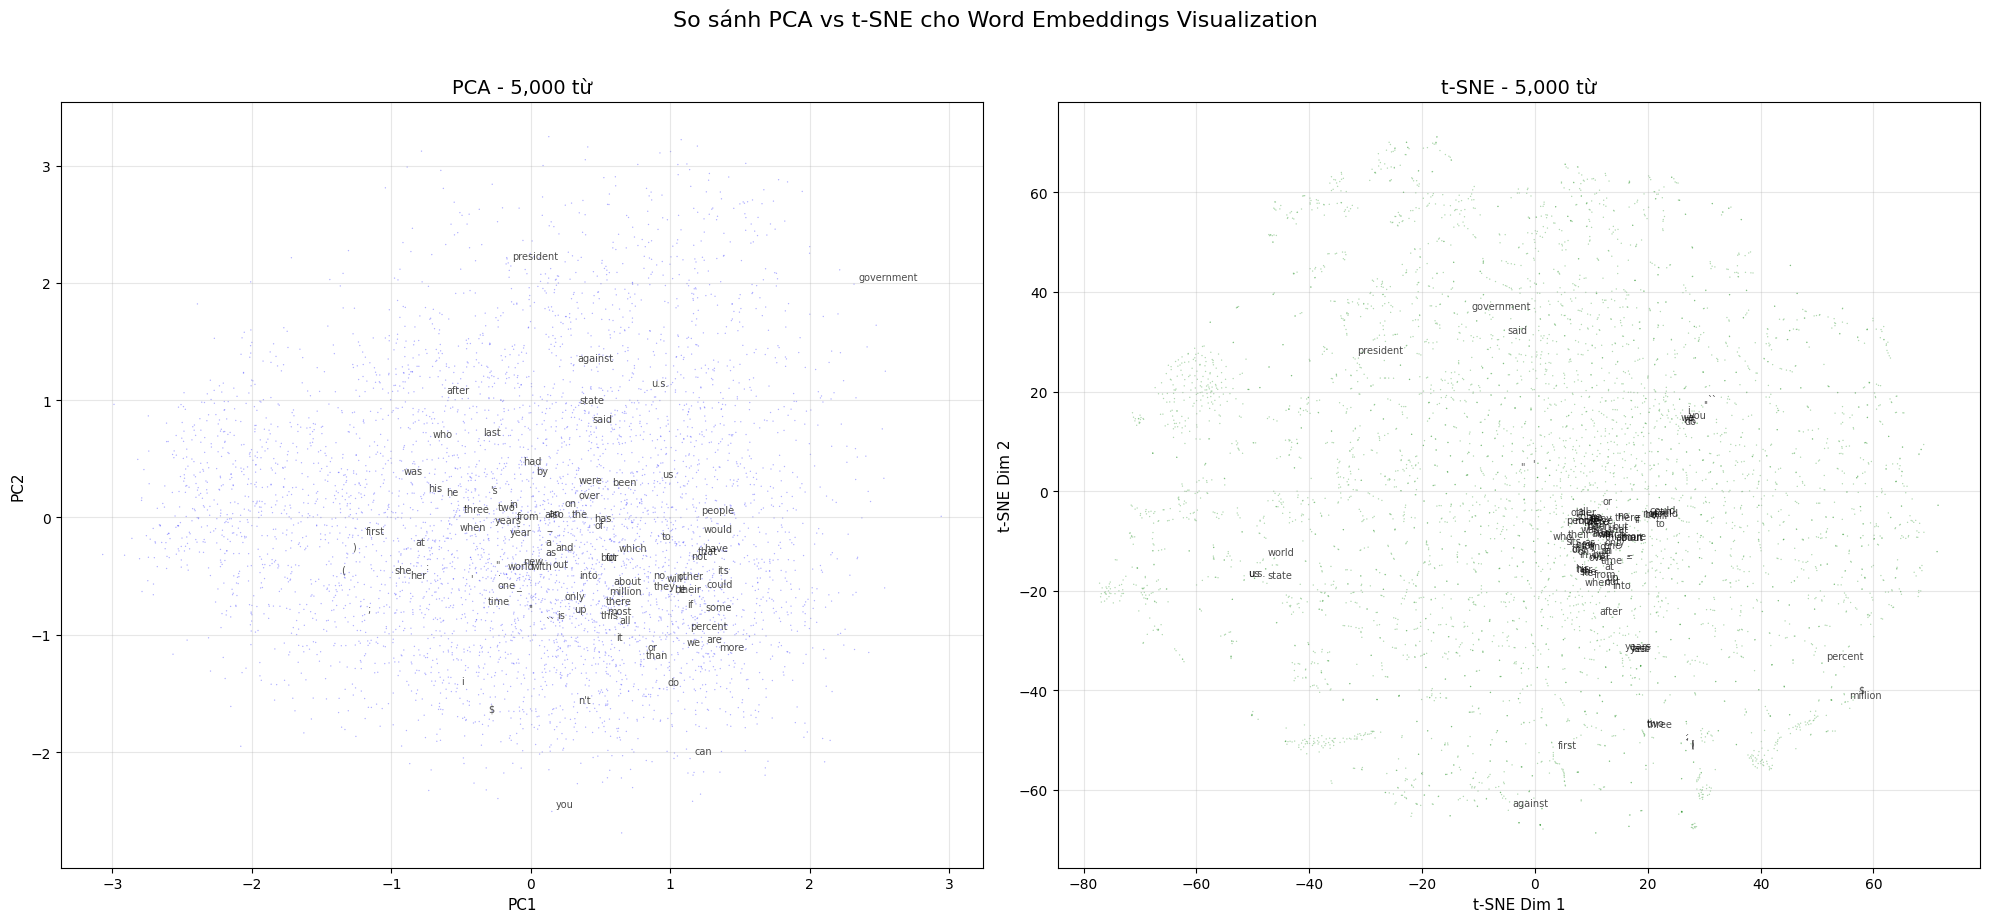

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# PCA plot
axes[0].scatter(vectors_2d_pca[:, 0], vectors_2d_pca[:, 1], 
               alpha=0.3, s=1, c='blue', edgecolors='none')
for i in range(100):  # Hiển thị 100 nhãn
    axes[0].annotate(words_to_visualize[i], 
                    xy=(vectors_2d_pca[i, 0], vectors_2d_pca[i, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=7, alpha=0.7)
axes[0].set_title(f'PCA - {NUM_WORDS:,} từ', fontsize=14)
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
axes[0].grid(True, alpha=0.3)

# t-SNE plot
axes[1].scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], 
               alpha=0.3, s=1, c='green', edgecolors='none')
for i in range(100):  # Hiển thị 100 nhãn
    axes[1].annotate(words_to_visualize[i], 
                    xy=(vectors_2d_tsne[i, 0], vectors_2d_tsne[i, 1]),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=7, alpha=0.7)
axes[1].set_title(f't-SNE - {NUM_WORDS:,} từ', fontsize=14)
axes[1].set_xlabel('t-SNE Dim 1', fontsize=11)
axes[1].set_ylabel('t-SNE Dim 2', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('So sánh PCA vs t-SNE cho Word Embeddings Visualization', 
            fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 8: Trực quan hóa nhóm từ cụ thể

### Mục đích thí nghiệm:
Kiểm chứng xem mô hình word embedding có **học được mối quan hệ ngữ nghĩa** hay không bằng cách quan sát các nhóm từ cùng chủ đề

### Các nhóm từ được chọn:
1. **Quốc gia**: america, china, japan, france, germany, russia, india, brazil
2. **Thủ đô**: washington, beijing, tokyo, paris, berlin, moscow, delhi, london
3. **Động vật**: dog, cat, lion, tiger, elephant, monkey, bird, fish
4. **Màu sắc**: red, blue, green, yellow, black, white, orange, purple
5. **Số**: one, two, three, four, five, six, seven, eight, nine, ten

### Giả thuyết:
- Nếu model tốt → các từ **cùng nhóm nên ở gần nhau** trong không gian vector
- Các nhóm khác nhau nên **tách biệt nhau**

### Kỹ thuật trực quan hóa:
- Mỗi nhóm có màu riêng
- Từ trong nhóm được highlight với marker lớn

In [37]:
# Định nghĩa các nhóm từ theo chủ đề
word_groups = {
    'Quốc gia': ['america', 'china', 'japan', 'france', 'germany', 'russia', 'india', 'brazil'],
    'Thủ đô': ['washington', 'beijing', 'tokyo', 'paris', 'berlin', 'moscow', 'delhi', 'london'],
    'Động vật': ['dog', 'cat', 'lion', 'tiger', 'elephant', 'monkey', 'bird', 'fish'],
    'Màu sắc': ['red', 'blue', 'green', 'yellow', 'black', 'white', 'orange', 'purple'],
    'Số': ['one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten']
}

# Lấy indices và positions cho các từ này
group_positions_tsne = {}
group_positions_pca = {}

for group_name, words in word_groups.items():
    positions_tsne = []
    positions_pca = []
    valid_words = []
    
    for word in words:
        if word in words_to_visualize:
            idx = words_to_visualize.index(word)
            positions_tsne.append(vectors_2d_tsne[idx])
            positions_pca.append(vectors_2d_pca[idx])
            valid_words.append(word)
    
    if positions_tsne:
        group_positions_tsne[group_name] = (np.array(positions_tsne), valid_words)
        group_positions_pca[group_name] = (np.array(positions_pca), valid_words)

print(f"Đã xác định {len(group_positions_tsne)} nhóm từ để trực quan hóa")

Đã xác định 5 nhóm từ để trực quan hóa


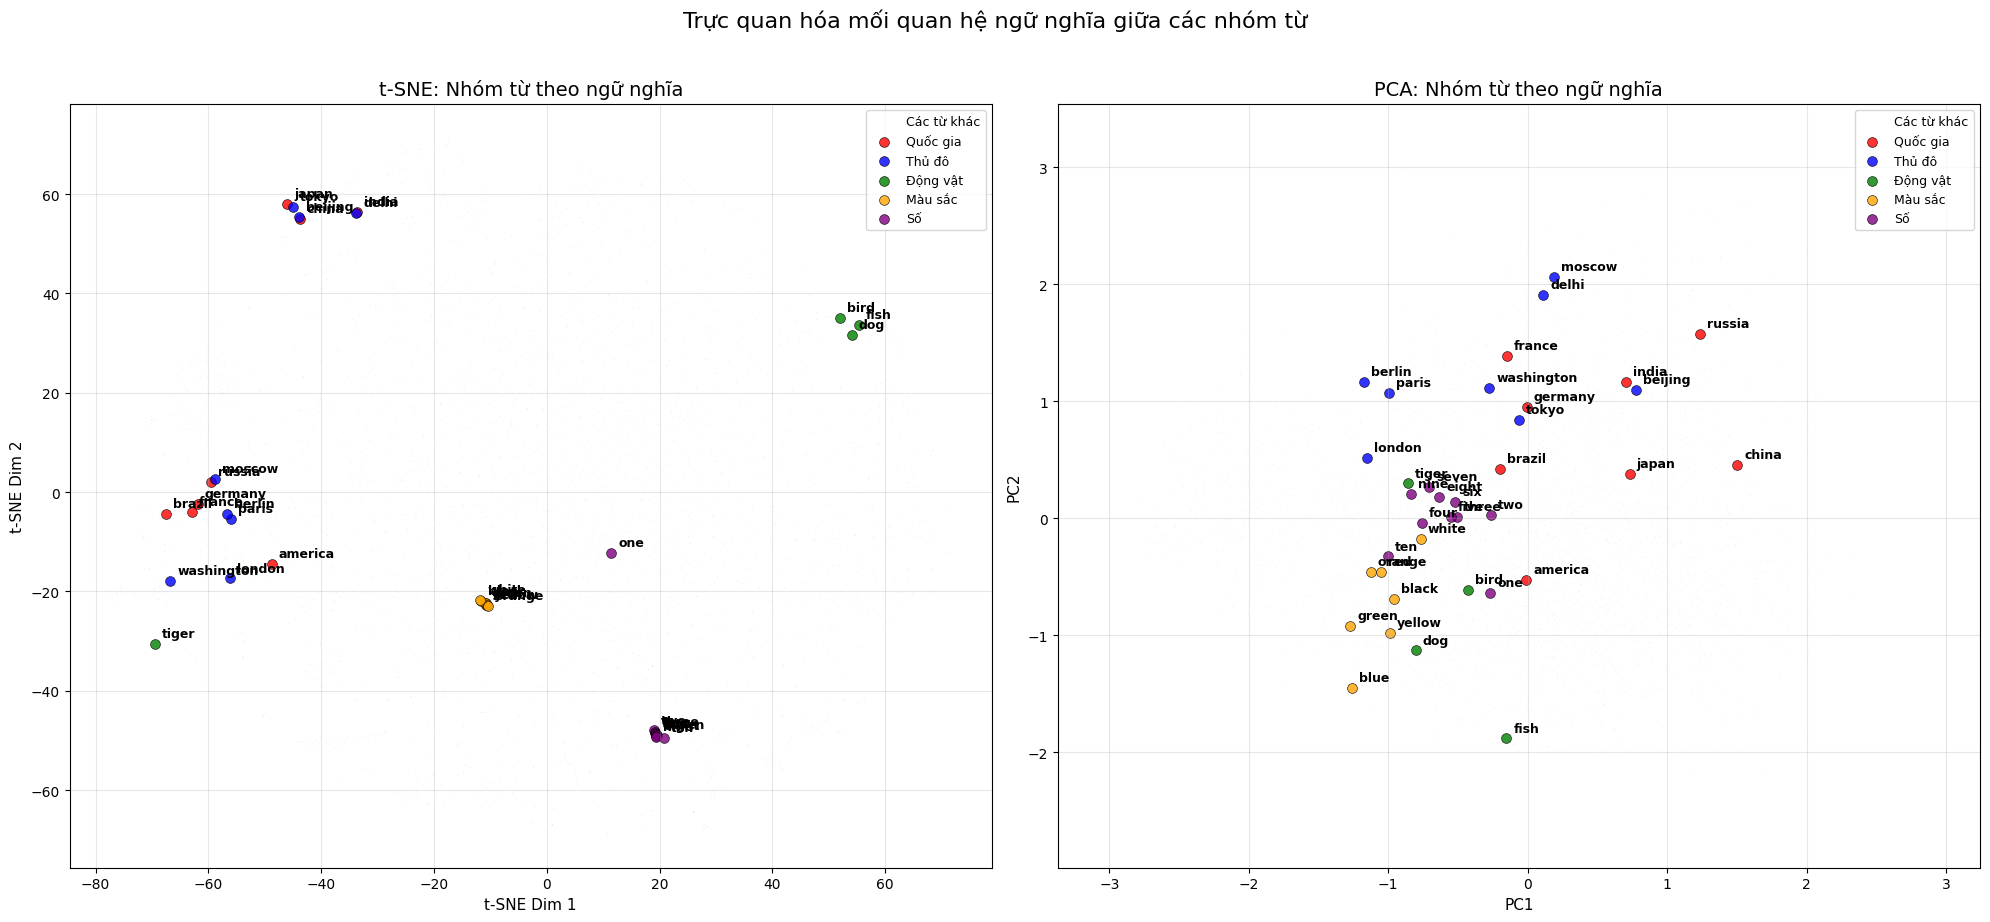

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

colors = ['red', 'blue', 'green', 'orange', 'purple']

# t-SNE plot với nhóm từ
axes[0].scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], 
               alpha=0.1, s=0.5, c='gray', edgecolors='none', label='Các từ khác')

for idx, (group_name, (positions, words)) in enumerate(group_positions_tsne.items()):
    color = colors[idx % len(colors)]
    axes[0].scatter(positions[:, 0], positions[:, 1], 
                   alpha=0.8, s=50, c=color, edgecolors='black', linewidth=0.5,
                   label=group_name)
    for i, word in enumerate(words):
        axes[0].annotate(word, xy=(positions[i, 0], positions[i, 1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, fontweight='bold')

axes[0].set_title(f't-SNE: Nhóm từ theo ngữ nghĩa', fontsize=14)
axes[0].set_xlabel('t-SNE Dim 1', fontsize=11)
axes[0].set_ylabel('t-SNE Dim 2', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# PCA plot với nhóm từ
axes[1].scatter(vectors_2d_pca[:, 0], vectors_2d_pca[:, 1], 
               alpha=0.1, s=0.5, c='gray', edgecolors='none', label='Các từ khác')

for idx, (group_name, (positions, words)) in enumerate(group_positions_pca.items()):
    color = colors[idx % len(colors)]
    axes[1].scatter(positions[:, 0], positions[:, 1], 
                   alpha=0.8, s=50, c=color, edgecolors='black', linewidth=0.5,
                   label=group_name)
    for i, word in enumerate(words):
        axes[1].annotate(word, xy=(positions[i, 0], positions[i, 1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=9, fontweight='bold')

axes[1].set_title(f'PCA: Nhóm từ theo ngữ nghĩa', fontsize=14)
axes[1].set_xlabel('PC1', fontsize=11)
axes[1].set_ylabel('PC2', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Trực quan hóa mối quan hệ ngữ nghĩa giữa các nhóm từ', 
            fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Phân tích kết quả nhóm từ:

**Quan sát kết quả:**

**1. t-SNE thể hiện rõ hơn PCA:**
- Các từ cùng nhóm **tập trung gần nhau** rõ ràng hơn
- Ví dụ: Các số (one, two, three...) tạo thành cluster riêng
- Các quốc gia và thủ đô thường ở gần nhau

**2. Mối quan hệ ngữ nghĩa:**
- Quốc gia và thủ đô có xu hướng gần nhau 
- Động vật tập trung riêng
- Màu sắc có thể phân tán hơn 

**3. Ý nghĩa:**
- Mô hình GloVe đã học được **semantic similarity**
- Từ cùng context/domain có vectors gần nhau

**4. Hạn chế:**
- Một số từ có thể không trong top 5,000 → không hiển thị
- 2D không thể hiện đầy đủ 100D → mất nhiều thông tin

## 9: Tìm từ gần nghĩa của `computer`

### Mục đích:
Minh họa ứng dụng thực tế của word embeddings: **Tìm từ đồng nghĩa/gần nghĩa**

### Phương pháp:
- Sử dụng **cosine similarity** để đo độ tương đồng giữa vectors
- Công thức: `similarity(A, B) = (A · B) / (||A|| × ||B||)`
- Giá trị: -1 (ngược nghĩa) → 0 (không liên quan) → 1 (giống nhau)

### Kỳ vọng:
Các từ liên quan đến máy tính

In [39]:
# Tìm 10 từ gần nghĩa nhất với 'computer'
target_word = 'computer'
print(f"Tìm các từ gần nghĩa nhất với '{target_word}':\n")

try:
    similar_words = model.most_similar(target_word, topn=10)
    
    print(f"{'Từ':<20} {'Độ tương đồng':>15}")
    print("-" * 37)
    for word, similarity in similar_words:
        print(f"{word:<20} {similarity:>15.4f}")
        
except KeyError:
    print(f"Từ '{target_word}' không có trong từ điển của mô hình.")

Tìm các từ gần nghĩa nhất với 'computer':

Từ                     Độ tương đồng
-------------------------------------
computers                     0.8752
software                      0.8373
technology                    0.7642
pc                            0.7366
hardware                      0.7290
internet                      0.7287
desktop                       0.7234
electronic                    0.7222
systems                       0.7198
computing                     0.7142


### Phân tích kết quả:

**Đánh giá chất lượng:**
- Kiểm tra xem các từ có **liên quan về mặt ngữ nghĩa** không

**Ý nghĩa:**
- Nếu kết quả hợp lý → model đã học được **mối quan hệ từ vựng**
- Có thể dùng cho: synonym expansion, semantic search, recommendation...

### Trực quan hóa từ 'computer' và các từ gần nghĩa

**Mục đích:**
- **Minh họa trực quan** vị trí của 'computer' và các từ gần nghĩa trong không gian 2D
- Xem chúng có **tập trung gần nhau** trong không gian t-SNE không

**Thiết kế biểu đồ:**
- **Plot 1 (Overview)**: Hiển thị toàn bộ 5,000 từ
  - Background: màu xám nhạt
  - Similar words: màu xanh dương (marker tròn)
  - Target word 'computer': màu đỏ (marker sao)
  
- **Plot 2 (Zoom)**: Phóng to khu vực xung quanh 'computer'
  - Dễ quan sát **mối quan hệ không gian** giữa các từ
  - Font size lớn hơn để dễ đọc

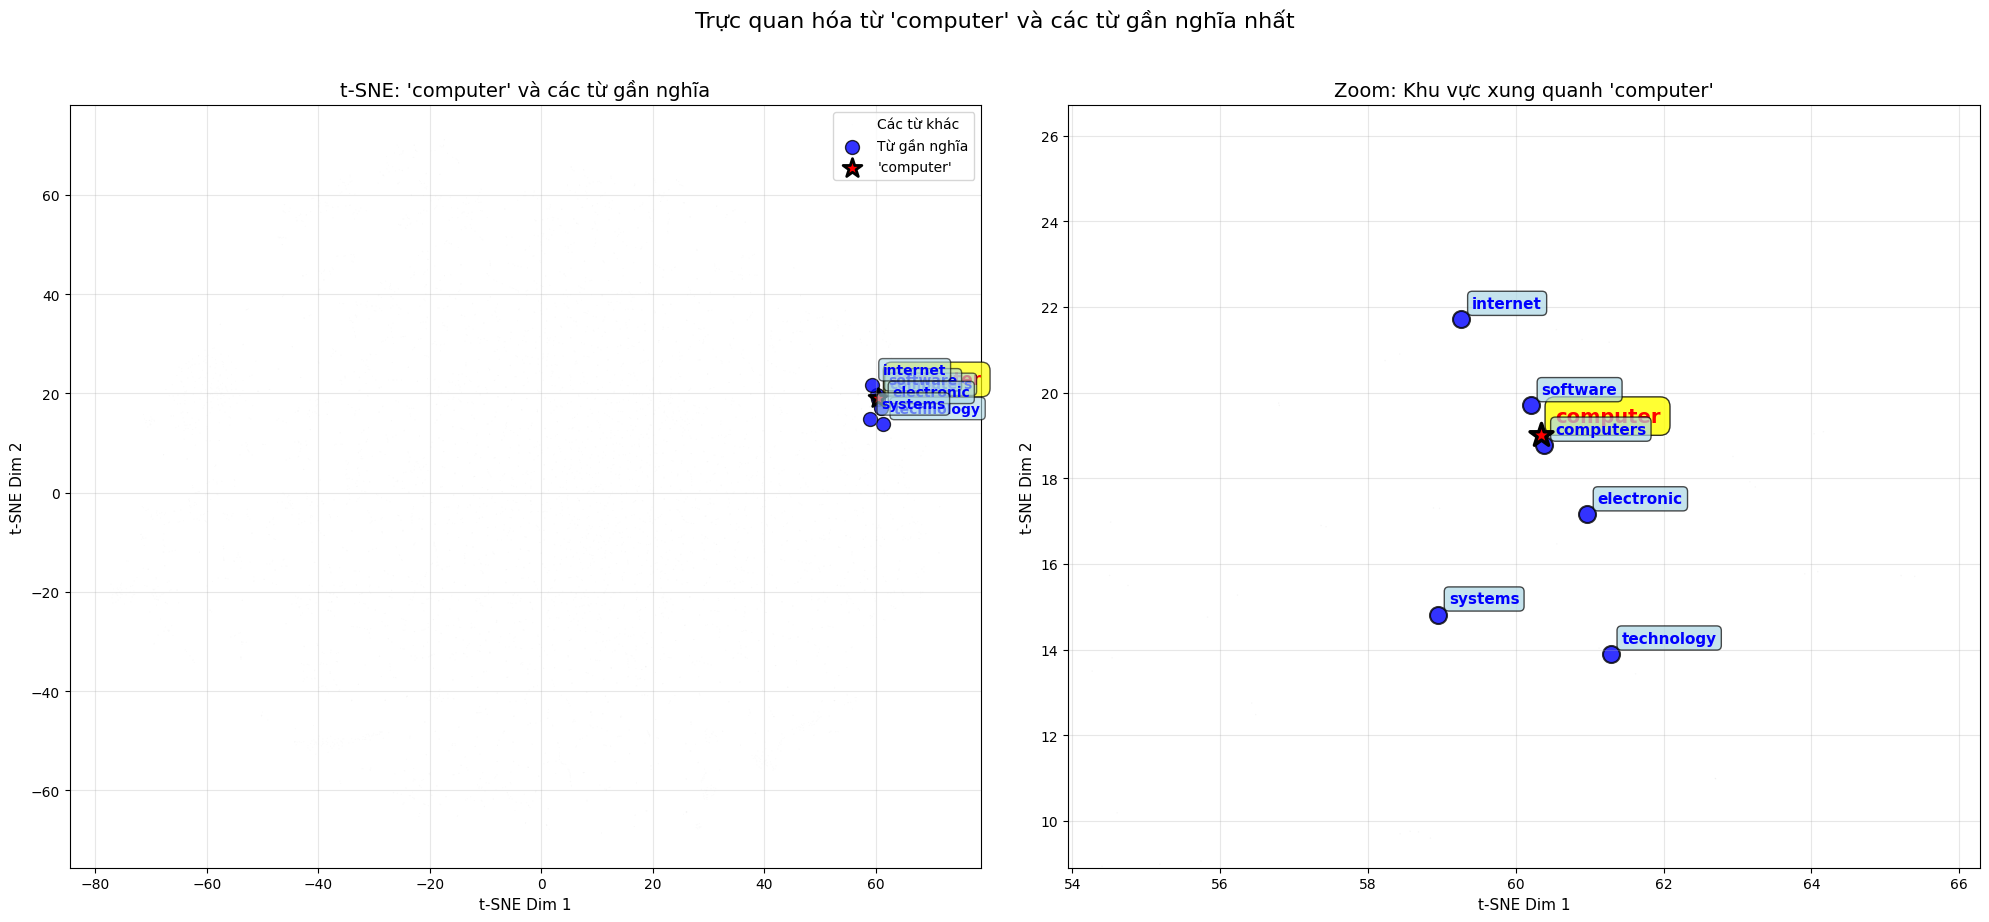


Đã trực quan hóa 'computer' và 6 từ gần nghĩa


In [40]:
# Lấy vị trí của 'computer' và các từ gần nghĩa trên biểu đồ t-SNE
target_word = 'computer'

if target_word in words_to_visualize:
    # Lấy các từ gần nghĩa
    similar_words = model.most_similar(target_word, topn=10)
    similar_word_list = [word for word, _ in similar_words]
    
    # Lấy vị trí của target word và similar words
    target_idx = words_to_visualize.index(target_word)
    target_pos = vectors_2d_tsne[target_idx]
    
    similar_positions = []
    valid_similar_words = []
    for word in similar_word_list:
        if word in words_to_visualize:
            idx = words_to_visualize.index(word)
            similar_positions.append(vectors_2d_tsne[idx])
            valid_similar_words.append(word)
    
    similar_positions = np.array(similar_positions)
    
    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    
    # Plot 1: t-SNE với highlighting
    axes[0].scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], 
                   alpha=0.1, s=0.5, c='lightgray', edgecolors='none', label='Các từ khác')
    
    # Highlight similar words
    axes[0].scatter(similar_positions[:, 0], similar_positions[:, 1], 
                   alpha=0.8, s=100, c='blue', edgecolors='black', linewidth=1,
                   label='Từ gần nghĩa', marker='o')
    
    # Highlight target word
    axes[0].scatter(target_pos[0], target_pos[1], 
                   alpha=1.0, s=200, c='red', edgecolors='black', linewidth=2,
                   label=f"'{target_word}'", marker='*')
    
    # Annotate target word
    axes[0].annotate(target_word, xy=(target_pos[0], target_pos[1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold', color='red',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))
    
    # Annotate similar words
    for i, word in enumerate(valid_similar_words):
        axes[0].annotate(word, xy=(similar_positions[i, 0], similar_positions[i, 1]),
                        xytext=(8, 8), textcoords='offset points',
                        fontsize=10, fontweight='bold', color='blue',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.6))
    
    axes[0].set_title(f"t-SNE: '{target_word}' và các từ gần nghĩa", fontsize=14)
    axes[0].set_xlabel('t-SNE Dim 1', fontsize=11)
    axes[0].set_ylabel('t-SNE Dim 2', fontsize=11)
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Zoom vào khu vực xung quanh
    # Tính bounding box cho zoom
    all_positions = np.vstack([target_pos.reshape(1, -1), similar_positions])
    x_min, x_max = all_positions[:, 0].min() - 5, all_positions[:, 0].max() + 5
    y_min, y_max = all_positions[:, 1].min() - 5, all_positions[:, 1].max() + 5
    
    # Vẽ zoom
    axes[1].scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], 
                   alpha=0.2, s=1, c='lightgray', edgecolors='none')
    
    axes[1].scatter(similar_positions[:, 0], similar_positions[:, 1], 
                   alpha=0.8, s=150, c='blue', edgecolors='black', linewidth=1.5,
                   marker='o')
    
    axes[1].scatter(target_pos[0], target_pos[1], 
                   alpha=1.0, s=300, c='red', edgecolors='black', linewidth=2.5,
                   marker='*', zorder=10)
    
    # Annotate trong zoom view
    axes[1].annotate(target_word, xy=(target_pos[0], target_pos[1]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=14, fontweight='bold', color='red',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))
    
    for i, word in enumerate(valid_similar_words):
        axes[1].annotate(word, xy=(similar_positions[i, 0], similar_positions[i, 1]),
                        xytext=(8, 8), textcoords='offset points',
                        fontsize=11, fontweight='bold', color='blue',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_min, y_max)
    axes[1].set_title(f"Zoom: Khu vực xung quanh '{target_word}'", fontsize=14)
    axes[1].set_xlabel('t-SNE Dim 1', fontsize=11)
    axes[1].set_ylabel('t-SNE Dim 2', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Trực quan hóa từ '{target_word}' và các từ gần nghĩa nhất", 
                fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\nĐã trực quan hóa '{target_word}' và {len(valid_similar_words)} từ gần nghĩa")
else:
    print(f"Từ '{target_word}' không có trong {NUM_WORDS} từ được chọn để trực quan hóa.")

### Nhận xét về trực quan hóa:

1. **Cluster hình thành**: Các từ gần nghĩa nên tạo thành một cluster gần 'computer'
2. **Khoảng cách ngữ nghĩa**: Từ càng gần về ý nghĩa → càng gần trong không gian 2D
3. **Tách biệt với từ khác**: Cluster 'computer' nên tách biệt với các chủ đề khác

## Kết luận

### Tổng kết kiến thức đạt được:

**1. Word Embeddings:**
- Biểu diễn từ dưới dạng **dense vectors** thay vì one-hot encoding
- Bắt được **mối quan hệ ngữ nghĩa** (từ gần nghĩa có vector gần nhau)
- Mô hình GloVe học từ dữ liệu corpus lớn

**2. Kỹ thuật giảm chiều:**

| Phương pháp | PCA | t-SNE |
|-------------|-----|-------|
| **Loại** | Tuyến tính | Phi tuyến |
| **Tốc độ** | Nhanh (O(n²d)) | Chậm (O(n² log n)) |
| **Bảo toàn** | Cấu trúc toàn cục | Cấu trúc cục bộ |
| **Cluster** | Mờ nhạt | Rõ ràng |
| **Ổn định** | Deterministic | Stochastic |

**3. So sánh PCA vs t-SNE:**

**PCA (Principal Component Analysis):**
   Ưu điểm:
   -  Nhanh và hiệu quả với dữ liệu lớn
   -  Kết quả ổn định, reproducible
   -  Bảo toàn khoảng cách toàn cục
   -  Phù hợp làm bước preprocessing
   Nhược điểm
   -  Chỉ bắt được quan hệ tuyến tính
   -  Cluster không rõ ràng
   -  Mất nhiều thông tin (chỉ giữ ~10% variance)

**t-SNE (t-Distributed Stochastic Neighbor Embedding):**
   Ưu điểm:
   -  Tạo cluster rõ ràng, trực quan
   -  Bắt được quan hệ phi tuyến
   -  Tốt cho trực quan hóa và presentation
   Nhược điểm:
   -  Chậm với dữ liệu lớn
   -  Không bảo toàn khoảng cách toàn cục
   -  Kết quả thay đổi mỗi lần chạy

**4. Quan sát về mối quan hệ ngữ nghĩa:**
- Các từ **cùng chủ đề tập trung gần nhau**: quốc gia, động vật, màu sắc, số
- Mô hình đã học được **semantic similarity** từ corpus

**5. Lựa chọn số lượng từ:**
- **5,000 từ** là điểm cân bằng tốt giữa:
  - Đủ lớn để quan sát patterns
  - Đủ nhỏ để t-SNE chạy được nhanh
  - Bao phủ hầu hết từ phổ biến

In [41]:
print('end')

end
